# ARIMA(p, 0, 0) Order Diagnostics

Строит ARIMA(p,0,0), то есть AR(p), для `log_return_1m`, где `p = 1..10`, и сравнивает:

- AIC / BIC;
- значимость коэффициентов;
- out-of-sample RMSE;
- directional accuracy.

По умолчанию используется условная AR(p)-оценка через `statsmodels.tsa.ar_model.AutoReg`, что эквивалентно ARIMA(p,0,0) для d=0 и хорошо подходит для быстрого перебора порядков на минутных данных. Forecast out-of-sample считается как one-step-ahead prediction с фактическими прошлыми значениями `y(t-1)..y(t-p)`, без refit на test.

In [11]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

try:
    display
except NameError:
    display = print

## Settings

In [12]:
DATASET_PATH = Path("model_artifacts/adausdt_minute_log_return_dataset.parquet")
OUTPUT_DIR = Path("model_artifacts/arima_order_diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "log_return_1m"
TIME_COL = "timestamp"

P_VALUES = list(range(1, 11))
TRAIN_FRACTION = 0.8

# None = весь ряд. Для быстрой первой диагностики оставь 500k-1M.
MAX_ROWS = 500_000
USE_TAIL = True

SIGNIFICANCE_ALPHA = 0.05

assert DATASET_PATH.exists(), DATASET_PATH

## Load Target Series

In [13]:
df = pd.read_parquet(DATASET_PATH, columns=[TIME_COL, TARGET_COL])
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True)
df = df.sort_values(TIME_COL).dropna(subset=[TARGET_COL]).reset_index(drop=True)

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.tail(MAX_ROWS).reset_index(drop=True) if USE_TAIL else df.head(MAX_ROWS).reset_index(drop=True)

y = df[TARGET_COL].astype("float64").to_numpy()
timestamps = df[TIME_COL]

split_idx = int(len(y) * TRAIN_FRACTION)
train_y = y[:split_idx]
test_y = y[split_idx:]

print("rows", len(df))
print("train", len(train_y), timestamps.iloc[0], "..", timestamps.iloc[split_idx - 1])
print("test", len(test_y), timestamps.iloc[split_idx], "..", timestamps.iloc[-1])
display(df.head())
display(df.tail())

rows 500000
train 400000 2025-02-19 18:40:00+00:00 .. 2025-11-24 13:19:00+00:00
test 100000 2025-11-24 13:20:00+00:00 .. 2026-02-01 23:59:00+00:00


,timestamp,log_return_1m
0,2025-02-19 18:40:00+00:00,-0.001448
1,2025-02-19 18:41:00+00:00,0.001711
2,2025-02-19 18:42:00+00:00,0.000263
3,2025-02-19 18:43:00+00:00,-0.000394
4,2025-02-19 18:44:00+00:00,-0.000789


,timestamp,log_return_1m
499995,2026-02-01 23:55:00+00:00,0.000700
499996,2026-02-01 23:56:00+00:00,0.001399
499997,2026-02-01 23:57:00+00:00,-0.002099
499998,2026-02-01 23:58:00+00:00,0.000350
499999,2026-02-01 23:59:00+00:00,0.001050


## Fit ARIMA(p,0,0) / AR(p)

In [14]:
def one_step_ar_predictions(params, p, y_full, start_idx, end_idx):
    """One-step-ahead AR(p) predictions using actual past y values."""
    names = list(params.index)
    const = float(params.get("const", 0.0))
    coefs = []
    for lag in range(1, p + 1):
        key = f"y.L{lag}"
        if key not in params.index:
            key = f"{TARGET_COL}.L{lag}"
        if key not in params.index:
            # AutoReg names can vary across statsmodels versions.
            matches = [name for name in names if name.endswith(f".L{lag}")]
            if not matches:
                raise KeyError(f"Cannot find AR coefficient for lag {lag}: {names}")
            key = matches[0]
        coefs.append(float(params[key]))

    preds = np.empty(end_idx - start_idx)
    for out_i, idx in enumerate(range(start_idx, end_idx)):
        lag_values = np.array([y_full[idx - lag] for lag in range(1, p + 1)], dtype="float64")
        preds[out_i] = const + float(np.dot(coefs, lag_values))
    return preds


metrics_rows = []
coef_rows = []
prediction_frames = []

for p in P_VALUES:
    print(f"fit AR({p})")
    result = AutoReg(train_y, lags=p, trend="c", old_names=False).fit()
    params = pd.Series(result.params, index=result.model.exog_names)
    pvalues = pd.Series(result.pvalues, index=result.model.exog_names)
    pred = one_step_ar_predictions(params, p, y, split_idx, len(y))

    rmse = float(np.sqrt(np.mean((test_y - pred) ** 2)))
    mae = float(np.mean(np.abs(test_y - pred)))
    pred_sign = np.sign(pred)
    true_sign = np.sign(test_y)
    nonzero_true_mask = true_sign != 0
    nonzero_both_mask = (true_sign != 0) & (pred_sign != 0)

    directional_accuracy = float((pred_sign == true_sign).mean())
    directional_accuracy_nonzero_true = float((pred_sign[nonzero_true_mask] == true_sign[nonzero_true_mask]).mean())
    directional_accuracy_nonzero_both = float((pred_sign[nonzero_both_mask] == true_sign[nonzero_both_mask]).mean())
    inverse_directional_accuracy_nonzero_true = float((pred_sign[nonzero_true_mask] == -true_sign[nonzero_true_mask]).mean())
    majority_directional_baseline = float(max((true_sign[nonzero_true_mask] > 0).mean(), (true_sign[nonzero_true_mask] < 0).mean()))

    ar_pvalues = []
    for name, value in params.items():
        pvalue = float(pvalues[name])
        coef_rows.append({
            "p": p,
            "term": name,
            "coefficient": float(value),
            "pvalue": pvalue,
            "significant": bool(pvalue < SIGNIFICANCE_ALPHA),
        })
        if name != "const":
            ar_pvalues.append(pvalue)

    metrics_rows.append({
        "p": p,
        "aic": float(result.aic),
        "bic": float(result.bic),
        "hqic": float(result.hqic),
        "rmse": rmse,
        "mae": mae,
        "directional_accuracy": directional_accuracy,
        "directional_accuracy_nonzero_true": directional_accuracy_nonzero_true,
        "directional_accuracy_nonzero_both": directional_accuracy_nonzero_both,
        "inverse_directional_accuracy_nonzero_true": inverse_directional_accuracy_nonzero_true,
        "majority_directional_baseline_nonzero_true": majority_directional_baseline,
        "true_positive_rate": float((true_sign > 0).mean()),
        "true_negative_rate": float((true_sign < 0).mean()),
        "true_zero_rate": float((true_sign == 0).mean()),
        "pred_positive_rate": float((pred_sign > 0).mean()),
        "pred_negative_rate": float((pred_sign < 0).mean()),
        "pred_zero_rate": float((pred_sign == 0).mean()),
        "significant_ar_coefficients": int(sum(np.array(ar_pvalues) < SIGNIFICANCE_ALPHA)),
        "total_ar_coefficients": int(len(ar_pvalues)),
        "all_ar_coefficients_significant": bool(all(np.array(ar_pvalues) < SIGNIFICANCE_ALPHA)),
        "max_ar_pvalue": float(np.max(ar_pvalues)) if ar_pvalues else np.nan,
        "min_ar_pvalue": float(np.min(ar_pvalues)) if ar_pvalues else np.nan,
    })

    prediction_frames.append(pd.DataFrame({
        "timestamp": timestamps.iloc[split_idx:].to_numpy(),
        "p": p,
        "actual": test_y,
        "prediction": pred,
    }))

metrics_df = pd.DataFrame(metrics_rows)
coef_df = pd.DataFrame(coef_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df)
display(coef_df.head(30))

fit AR(1)
fit AR(2)
fit AR(3)
fit AR(4)
fit AR(5)
fit AR(6)
fit AR(7)
fit AR(8)
fit AR(9)
fit AR(10)


,p,aic,bic,hqic,rmse,mae,directional_accuracy,directional_accuracy_nonzero_true,directional_accuracy_nonzero_both,inverse_directional_accuracy_nonzero_true,majority_directional_baseline_nonzero_true,true_positive_rate,true_negative_rate,true_zero_rate,pred_positive_rate,pred_negative_rate,pred_zero_rate,significant_ar_coefficients,total_ar_coefficients,all_ar_coefficients_significant,max_ar_pvalue,min_ar_pvalue
0,1,-4.033492e+06,-4.033459e+06,-4.033483e+06,0.001111,0.000735,0.40011,0.470430,0.470430,0.529570,0.500165,0.42512,0.4254,0.14948,0.42511,0.57489,0.0,1,1,True,0.000000e+00,0.0
1,2,-4.033783e+06,-4.033740e+06,-4.033771e+06,0.001111,0.000735,0.39951,0.469724,0.469724,0.530276,0.500165,0.42512,0.4254,0.14948,0.48545,0.51455,0.0,2,2,True,6.463967e-68,0.0
2,3,-4.034021e+06,-4.033967e+06,-4.034005e+06,0.001112,0.000735,0.39943,0.469630,0.469630,0.530370,0.500165,0.42512,0.4254,0.14948,0.49493,0.50507,0.0,3,3,True,1.791767e-56,0.0
3,4,-4.034224e+06,-4.034158e+06,-4.034205e+06,0.001112,0.000735,0.40084,0.471288,0.471288,0.528712,0.500165,0.42512,0.4254,0.14948,0.49599,0.50401,0.0,4,4,True,2.265642e-43,0.0
4,5,-4.034217e+06,-4.034141e+06,-4.034195e+06,0.001112,0.000735,0.40072,0.471147,0.471147,0.528853,0.500165,0.42512,0.4254,0.14948,0.49596,0.50404,0.0,5,5,True,1.521929e-02,0.0
5,6,-4.034238e+06,-4.034151e+06,-4.034214e+06,0.001112,0.000735,0.40033,0.470689,0.470689,0.529311,0.500165,0.42512,0.4254,0.14948,0.49554,0.50446,0.0,6,6,True,1.563693e-03,0.0
6,7,-4.034307e+06,-4.034209e+06,-4.034279e+06,0.001112,0.000735,0.40106,0.471547,0.471547,0.528453,0.500165,0.42512,0.4254,0.14948,0.49575,0.50425,0.0,7,7,True,3.984124e-03,0.0
7,8,-4.034610e+06,-4.034501e+06,-4.034579e+06,0.001112,0.000736,0.40122,0.471735,0.471735,0.528265,0.500165,0.42512,0.4254,0.14948,0.49733,0.50267,0.0,8,8,True,1.084715e-03,0.0
8,9,-4.034604e+06,-4.034484e+06,-4.034570e+06,0.001112,0.000736,0.40126,0.471782,0.471782,0.528218,0.500165,0.42512,0.4254,0.14948,0.49662,0.50338,0.0,9,9,True,8.512481e-03,0.0
9,10,-4.034632e+06,-4.034501e+06,-4.034594e+06,0.001112,0.000736,0.40169,0.472288,0.472288,0.527712,0.500165,0.42512,0.4254,0.14948,0.49688,0.50312,0.0,9,10,False,6.651223e-02,0.0


,p,term,coefficient,pvalue,significant
0,1,const,-0.000001,5.886167e-01,False
1,1,y.L1,0.133252,0.000000e+00,True
2,2,const,-0.000001,5.974850e-01,False
3,2,y.L1,0.129587,0.000000e+00,True
4,2,y.L2,0.027523,6.463967e-68,True
5,3,const,-0.000001,5.881516e-01,False
6,3,y.L1,0.130276,0.000000e+00,True
7,3,y.L2,0.030767,4.374708e-83,True
8,3,y.L3,-0.025029,1.791767e-56,True
9,4,const,-0.000001,5.797710e-01,False


## Directional Accuracy Note

`directional_accuracy` ??????? `sign(pred) == sign(y_true)` ? ???????? `y_true`. ??? ???????? ??????????? ????? ????? ???? ?????, ? AR-??????? ????? ??????? ?? ????? ????? ????, ??????? ????? ?????? ????????????? ????????? ????????. ??????? ????????????? ????????? `directional_accuracy_nonzero_true` ? majority baseline ?????? ?? ??????? `y_true != 0`.


## Plots

WindowsPath('model_artifacts/arima_order_diagnostics/arima_order_metrics.png')

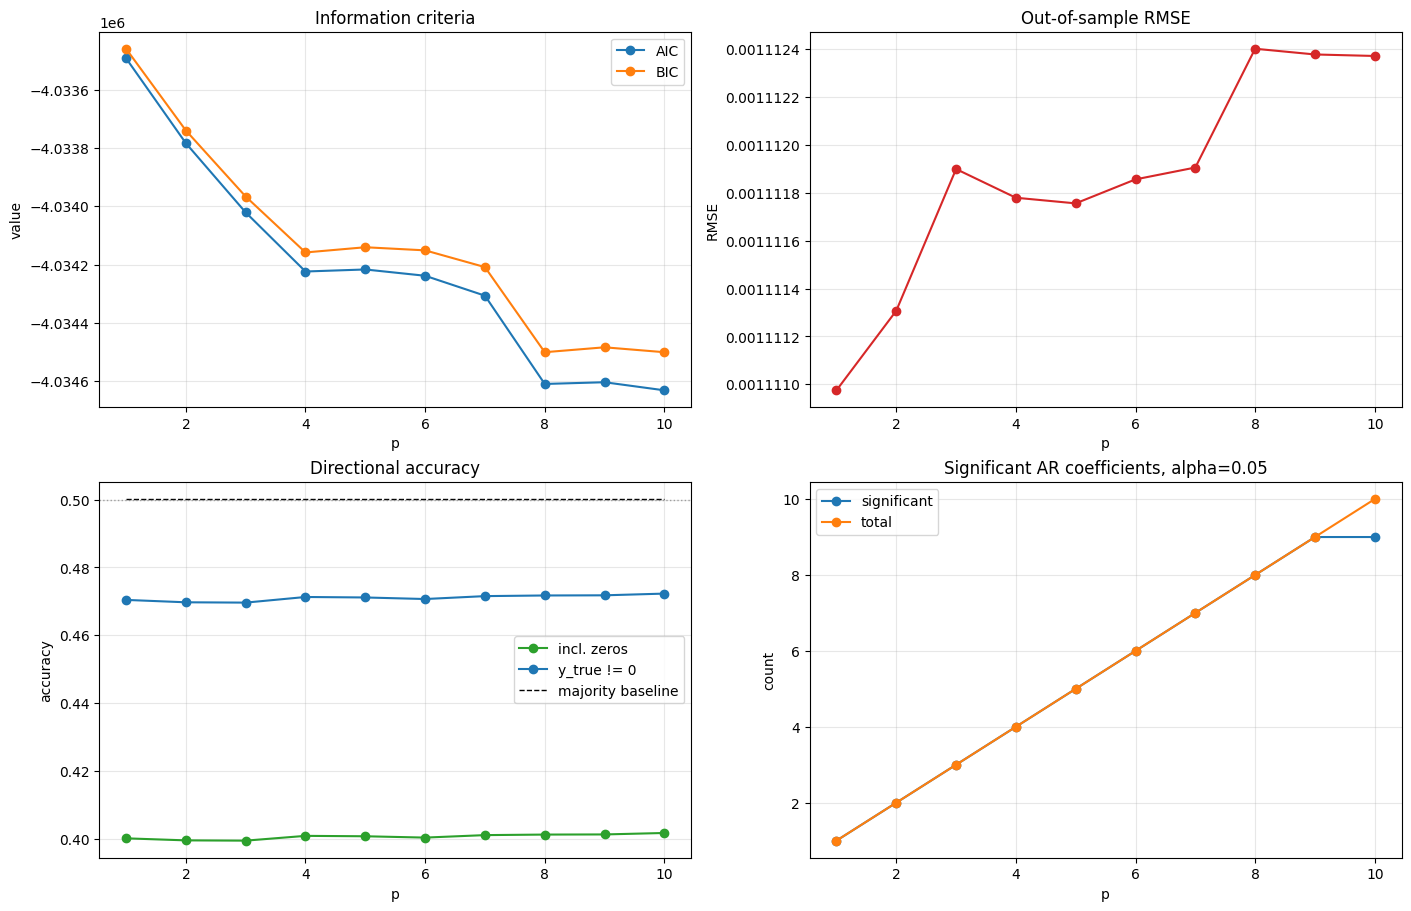

In [15]:
plt.style.use("default")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(metrics_df["p"], metrics_df["aic"], marker="o", label="AIC")
axes[0, 0].plot(metrics_df["p"], metrics_df["bic"], marker="o", label="BIC")
axes[0, 0].set_title("Information criteria")
axes[0, 0].set_xlabel("p")
axes[0, 0].set_ylabel("value")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df["p"], metrics_df["rmse"], marker="o", color="tab:red")
axes[0, 1].set_title("Out-of-sample RMSE")
axes[0, 1].set_xlabel("p")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df["p"], metrics_df["directional_accuracy"], marker="o", color="tab:green", label="incl. zeros")
axes[1, 0].plot(metrics_df["p"], metrics_df["directional_accuracy_nonzero_true"], marker="o", color="tab:blue", label="y_true != 0")
axes[1, 0].plot(metrics_df["p"], metrics_df["majority_directional_baseline_nonzero_true"], linestyle="--", color="black", linewidth=1, label="majority baseline")
axes[1, 0].axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.7)
axes[1, 0].set_title("Directional accuracy")
axes[1, 0].set_xlabel("p")
axes[1, 0].set_ylabel("accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df["p"], metrics_df["significant_ar_coefficients"], marker="o", label="significant")
axes[1, 1].plot(metrics_df["p"], metrics_df["total_ar_coefficients"], marker="o", label="total")
axes[1, 1].set_title(f"Significant AR coefficients, alpha={SIGNIFICANCE_ALPHA}")
axes[1, 1].set_xlabel("p")
axes[1, 1].set_ylabel("count")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plot_path = OUTPUT_DIR / "arima_order_metrics.png"
fig.savefig(plot_path, dpi=160)
plot_path

WindowsPath('model_artifacts/arima_order_diagnostics/arima_coefficient_significance.png')

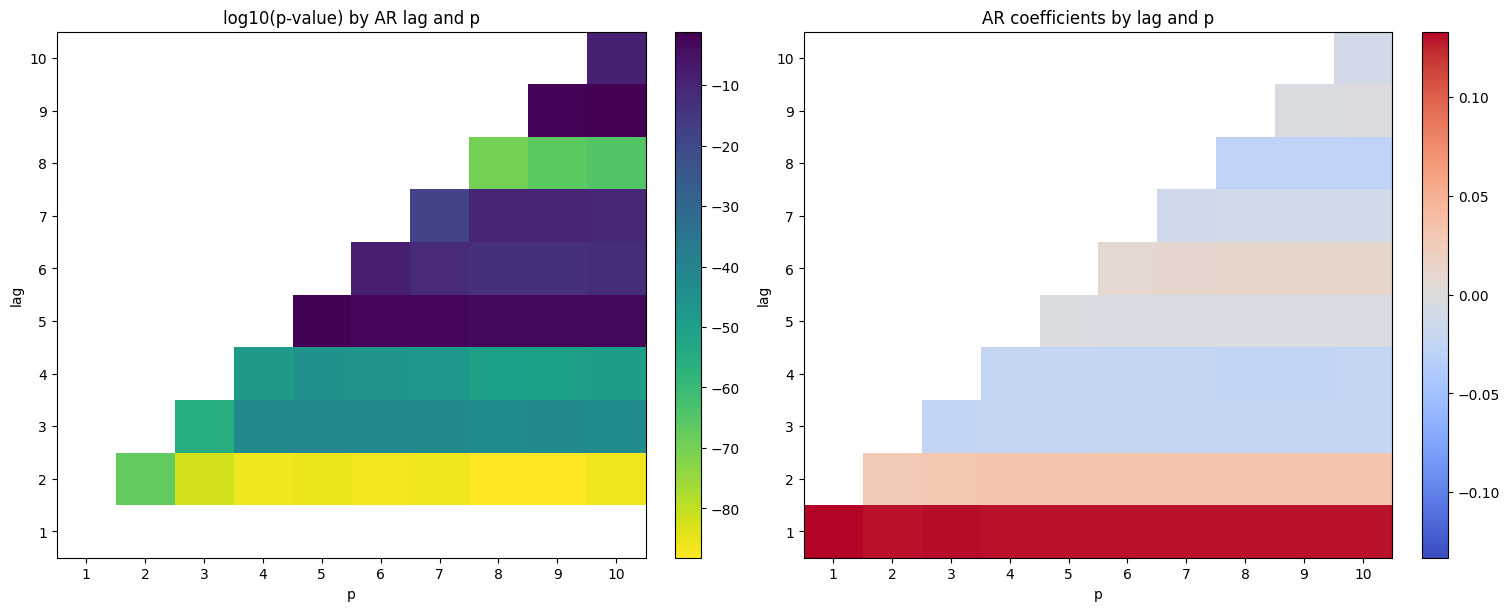

In [16]:
ar_coef_df = coef_df[coef_df["term"] != "const"].copy()
ar_coef_df["lag"] = ar_coef_df["term"].str.extract(r"L(\d+)").astype(int)

pivot_pvalues = ar_coef_df.pivot(index="lag", columns="p", values="pvalue")
pivot_coefs = ar_coef_df.pivot(index="lag", columns="p", values="coefficient")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

im0 = axes[0].imshow(np.log10(pivot_pvalues), aspect="auto", origin="lower", cmap="viridis_r")
axes[0].set_title("log10(p-value) by AR lag and p")
axes[0].set_xlabel("p")
axes[0].set_ylabel("lag")
axes[0].set_xticks(range(len(pivot_pvalues.columns)))
axes[0].set_xticklabels(pivot_pvalues.columns)
axes[0].set_yticks(range(len(pivot_pvalues.index)))
axes[0].set_yticklabels(pivot_pvalues.index)
fig.colorbar(im0, ax=axes[0])

max_abs_coef = np.nanmax(np.abs(pivot_coefs.to_numpy()))
im1 = axes[1].imshow(pivot_coefs, aspect="auto", origin="lower", cmap="coolwarm", vmin=-max_abs_coef, vmax=max_abs_coef)
axes[1].set_title("AR coefficients by lag and p")
axes[1].set_xlabel("p")
axes[1].set_ylabel("lag")
axes[1].set_xticks(range(len(pivot_coefs.columns)))
axes[1].set_xticklabels(pivot_coefs.columns)
axes[1].set_yticks(range(len(pivot_coefs.index)))
axes[1].set_yticklabels(pivot_coefs.index)
fig.colorbar(im1, ax=axes[1])

coef_plot_path = OUTPUT_DIR / "arima_coefficient_significance.png"
fig.savefig(coef_plot_path, dpi=160)
coef_plot_path

## Save Outputs

In [17]:
metrics_df.to_csv(OUTPUT_DIR / "arima_order_metrics.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "arima_coefficients.csv", index=False)
predictions_df.to_parquet(OUTPUT_DIR / "arima_oos_predictions.parquet", index=False, compression="zstd")

best = {
    "best_aic_p": int(metrics_df.loc[metrics_df["aic"].idxmin(), "p"]),
    "best_bic_p": int(metrics_df.loc[metrics_df["bic"].idxmin(), "p"]),
    "best_rmse_p": int(metrics_df.loc[metrics_df["rmse"].idxmin(), "p"]),
    "best_directional_accuracy_p": int(metrics_df.loc[metrics_df["directional_accuracy"].idxmax(), "p"]),
    "best_directional_accuracy_nonzero_true_p": int(metrics_df.loc[metrics_df["directional_accuracy_nonzero_true"].idxmax(), "p"]),
}

report = {
    "dataset": str(DATASET_PATH),
    "target": TARGET_COL,
    "rows_used": int(len(df)),
    "max_rows": MAX_ROWS,
    "use_tail": USE_TAIL,
    "train_fraction": TRAIN_FRACTION,
    "train_rows": int(len(train_y)),
    "test_rows": int(len(test_y)),
    "p_values": P_VALUES,
    "best": best,
    "metrics": metrics_df.to_dict(orient="records"),
    "plots": {
        "metrics": str(plot_path),
        "coefficient_significance": str(coef_plot_path),
    },
}
(OUTPUT_DIR / "arima_order_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

print("saved to", OUTPUT_DIR)
best

saved to model_artifacts\arima_order_diagnostics


{'best_aic_p': 10,
 'best_bic_p': 10,
 'best_rmse_p': 1,
 'best_directional_accuracy_p': 10,
 'best_directional_accuracy_nonzero_true_p': 10}